# Submission Validation vs Ground Truth

This notebook validates the generated submission file by:
1. Checking format compliance against `sample_submission.csv`.
2. Comparing the category distribution against the Historical Ground Truth.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Paths
SUBMISSION_PATH = 'submission_darts_5class.csv'
GT_PATH = '../dataset/data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-komponen-data.csv'
SAMPLE_SUB_PATH = '../dataset/sample_submission.csv'

## 1. Load Data

In [2]:
if os.path.exists(SUBMISSION_PATH):
    df_sub = pd.read_csv(SUBMISSION_PATH)
    print("Submission loaded.")
else:
    print("Submission file not found. Run the forecasting pipeline first.")

if os.path.exists(GT_PATH):
    df_gt = pd.read_csv(GT_PATH)
    print("Ground Truth loaded.")
else:
    print("Ground Truth file not found.")

Submission loaded.
Ground Truth loaded.


## 2. Format Validation

In [3]:
if os.path.exists(SAMPLE_SUB_PATH):
    df_sample = pd.read_csv(SAMPLE_SUB_PATH)
    
    # Check Columns
    if list(df_sub.columns) == list(df_sample.columns):
        print("✅ Column names match sample submission.")
    else:
        print(f"❌ Column mismatch! Found: {list(df_sub.columns)}, Expected: {list(df_sample.columns)}")
    
    # Check ID Count
    if len(df_sub) == len(df_sample):
        print(f"✅ Row count matches sample submission ({len(df_sub)}).")
    else:
        print(f"⚠️ Row count mismatch (Sub: {len(df_sub)}, Sample: {len(df_sample)}).")
else:
    print("Sample submission not found. Skipping format check.")

✅ Column names match sample submission.
✅ Row count matches sample submission (455).


## 3. Distribution Comparison

Ground Truth Distribution:
kategori
SEDANG                0.769714
BAIK                  0.126857
TIDAK SEHAT           0.097429
TIDAK ADA DATA        0.005714
SANGAT TIDAK SEHAT    0.000286
Name: proportion, dtype: float64

Submission Distribution:
category
SEDANG         0.815385
BAIK           0.164835
TIDAK SEHAT    0.019780
Name: proportion, dtype: float64


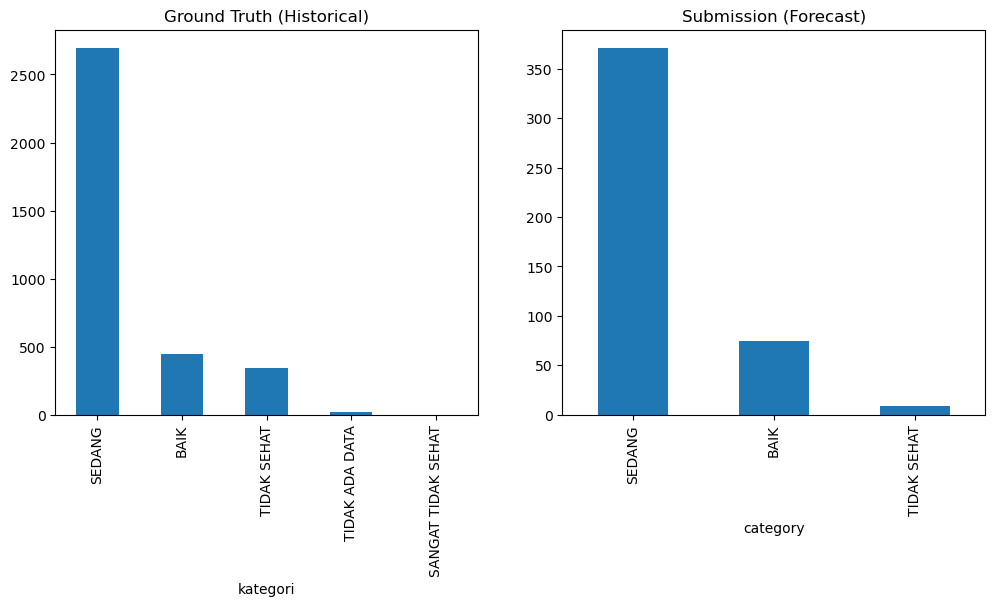

In [4]:
# Normalize GT column name if needed
if 'categori' in df_gt.columns:
    gt_col = 'categori'
elif 'kategori' in df_gt.columns:
    gt_col = 'kategori'
else:
    gt_col = None

if gt_col:
    print("Ground Truth Distribution:")
    print(df_gt[gt_col].value_counts(normalize=True))
    print("\nSubmission Distribution:")
    print(df_sub['category'].value_counts(normalize=True))
    
    # Simple Plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    df_gt[gt_col].value_counts().plot(kind='bar', ax=ax[0], title='Ground Truth (Historical)')
    df_sub['category'].value_counts().plot(kind='bar', ax=ax[1], title='Submission (Forecast)')
    plt.show()
else:
    print("Could not identify category column in Ground Truth.")

EVALUATION: Submission vs Ground Truth (Sep-Nov 2025)
Matched predictions: 455 / 455

🎯 F1-Score (Macro):    0.5212
🎯 F1-Score (Weighted): 0.8111

Classification Report:
              precision    recall  f1-score   support

        BAIK       0.56      0.67      0.61        63
      SEDANG       0.89      0.89      0.89       368
 TIDAK SEHAT       0.11      0.05      0.06        22

   micro avg       0.82      0.82      0.82       453
   macro avg       0.52      0.54      0.52       453
weighted avg       0.80      0.82      0.81       453



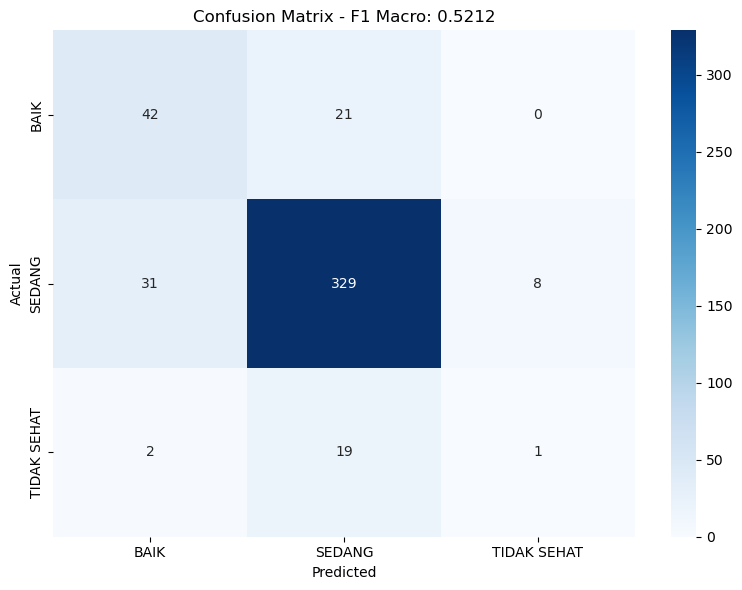


Per-Category Analysis:

BAIK:
  Ground Truth: 63 samples
  Predicted: 75 samples
  Correctly predicted: 42 (66.7%)

SEDANG:
  Ground Truth: 368 samples
  Predicted: 371 samples
  Correctly predicted: 329 (89.4%)

TIDAK SEHAT:
  Ground Truth: 22 samples
  Predicted: 9 samples
  Correctly predicted: 1 (4.5%)


In [5]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns

# Prepare Ground Truth for matching
df_gt['year'] = df_gt['periode_data'] // 100
df_gt['month'] = df_gt['periode_data'] % 100
df_gt['day'] = df_gt['tanggal']
df_gt['tanggal_parsed'] = pd.to_datetime(df_gt[['year', 'month', 'day']], errors='coerce')

# Map station names
station_map = {
    'DKI1 Bunderan HI': 'DKI1',
    'DKI1 Bundaran Hotel Indonesia (HI)': 'DKI1',
    'DKI1 Bundaran Hotel Indonesia HI': 'DKI1',
    'DKI2 Kelapa Gading': 'DKI2',
    'DKI3 Jagakarsa': 'DKI3',
    'DKI4 Lubang Buaya': 'DKI4',
    'DKI5 Kebon Jeruk': 'DKI5',
    'DKI5 Kebon Jeruk Jakarta Barat': 'DKI5'
}
df_gt['stasiun_mapped'] = df_gt['stasiun'].map(station_map).fillna(df_gt['stasiun'])

# Filter to Sep-Nov 2025 (submission period)
df_gt_2025 = df_gt[(df_gt['tanggal_parsed'] >= '2025-09-01') & 
                    (df_gt['tanggal_parsed'] <= '2025-11-30')].copy()

# Create ID column
df_gt_2025['id'] = df_gt_2025['tanggal_parsed'].dt.strftime('%Y-%m-%d') + '_' + df_gt_2025['stasiun_mapped']

# Map to 3 categories if needed
def map_to_3_categories(cat):
    if cat in ['SANGAT TIDAK SEHAT', 'BERBAHAYA']:
        return 'TIDAK SEHAT'
    return cat

# Find category column in ground truth
cat_col = 'target_kategori' if 'target_kategori' in df_gt_2025.columns else 'kategori'
df_gt_2025['kategori_mapped'] = df_gt_2025[cat_col].apply(map_to_3_categories)

# Merge with submission
merged = df_sub.merge(df_gt_2025[['id', 'kategori_mapped']], on='id', how='left')
merged = merged.dropna(subset=['kategori_mapped'])

if len(merged) > 0:
    y_true = merged['kategori_mapped'].values
    y_pred = merged['category'].values
    
    # Calculate F1 scores
    f1_macro = f1_score(y_true, y_pred, average='macro', labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
    f1_weighted = f1_score(y_true, y_pred, average='weighted', labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
    
    print(f"{'='*70}")
    print(f"EVALUATION: Submission vs Ground Truth (Sep-Nov 2025)")
    print(f"{'='*70}")
    print(f"Matched predictions: {len(merged)} / {len(df_sub)}")
    print(f"\n🎯 F1-Score (Macro):    {f1_macro:.4f}")
    print(f"🎯 F1-Score (Weighted): {f1_weighted:.4f}")
    
    print(f"\n{'='*70}")
    print(f"Classification Report:")
    print(f"{'='*70}")
    print(classification_report(y_true, y_pred, 
                                labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'],
                                target_names=['BAIK', 'SEDANG', 'TIDAK SEHAT'],
                                zero_division=0))
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(y_true, y_pred, labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['BAIK', 'SEDANG', 'TIDAK SEHAT'],
                yticklabels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
    plt.title(f'Confusion Matrix - F1 Macro: {f1_macro:.4f}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    
    # Per-category analysis
    print(f"\n{'='*70}")
    print(f"Per-Category Analysis:")
    print(f"{'='*70}")
    for cat in ['BAIK', 'SEDANG', 'TIDAK SEHAT']:
        true_count = (y_true == cat).sum()
        pred_count = (y_pred == cat).sum()
        correct = ((y_true == cat) & (y_pred == cat)).sum()
        
        if true_count > 0:
            accuracy_cat = correct / true_count
            print(f"\n{cat}:")
            print(f"  Ground Truth: {true_count} samples")
            print(f"  Predicted: {pred_count} samples")
            print(f"  Correctly predicted: {correct} ({100*accuracy_cat:.1f}%)")
else:
    print("⚠️ No matching records found between submission and ground truth!")

## 4. F1-Macro Score Evaluation